In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

In [8]:
# ── Configuration (identical to V1) ──────────────────────────────────────────
DATA_ROOT    = Path("mm-fit")
FS_TARGET    = 50.0
DT_MS        = int(round(1000.0 / FS_TARGET))   # 20 ms
WINDOW_SIZE  = 250                               # 5 s @ 50 Hz
STRIDE       = int(0.2 * FS_TARGET)             # 10 samples

TRAIN_IDS    = [1, 2, 3, 4, 6, 7, 8, 16, 17, 18]

EXERCISE_ORDER = [
    "squats",
    "lunges",
    "bicep_curls",
    "situps",
    "pushups",
    "tricep_extensions",
    "dumbbell_rows",
    "jumping_jacks",
    "dumbbell_shoulder_press",
    "lateral_shoulder_raises",
    "non-exercise",
]
label_to_id = {name: i for i, name in enumerate(EXERCISE_ORDER)}
id_to_label = {i: name for name, i in label_to_id.items()}
N_CLASSES   = len(EXERCISE_ORDER)

In [9]:
# ── Helper functions ──────────────────────────────────────────────────────────

def load_session_raw(session_id: int):
    w    = f"w{session_id:02d}"
    base = DATA_ROOT / w
    acc  = np.load(base / f"{w}_sw_r_acc.npy")
    gyr  = np.load(base / f"{w}_sw_r_gyr.npy")
    labels = pd.read_csv(
        base / f"{w}_labels.csv",
        header=None, names=["start", "end", "reps", "exercise"]
    )
    return acc, gyr, labels


def assign_labels_by_frame(frames, labels_df):
    y = np.full(frames.shape[0], label_to_id["non-exercise"], dtype=np.int32)
    for _, row in labels_df.iterrows():
        ex = row["exercise"]
        if ex not in label_to_id:
            continue
        mask = (frames >= int(row["start"])) & (frames <= int(row["end"]))
        y[mask] = label_to_id[ex]
    return y


def resample_to_labels(acc, gyr, labels_df):
    """Resamples to 50 Hz and returns per-sample labels only (no X needed)."""
    acc = acc[np.argsort(acc[:, 1])]
    gyr = gyr[np.argsort(gyr[:, 1])]

    acc_ts = acc[:, 1].astype(np.float64)
    gyr_ts = gyr[:, 1].astype(np.float64)

    t_start = max(acc_ts.min(), gyr_ts.min())
    t_end   = min(acc_ts.max(), gyr_ts.max())
    new_ts  = np.arange(t_start, t_end + 1, DT_MS, dtype=np.float64)

    acc_frames = acc[:, 0].astype(np.int64)
    acc_labels = assign_labels_by_frame(acc_frames, labels_df)

    nn = np.searchsorted(acc_ts, new_ts, side="left")
    nn = np.clip(nn, 0, len(acc_ts) - 1)
    prev = np.clip(nn - 1, 0, len(acc_ts) - 1)
    choose_prev = np.abs(acc_ts[prev] - new_ts) < np.abs(acc_ts[nn] - new_ts)
    nn_idx = np.where(choose_prev, prev, nn)

    return acc_labels[nn_idx].astype(np.int32)


def majority_window_labels(y, stride=STRIDE):
    """Returns majority-vote label for every sliding window over y."""
    starts = np.arange(0, len(y) - WINDOW_SIZE + 1, stride, dtype=np.int32)
    pref   = np.zeros((N_CLASSES, len(y) + 1), dtype=np.int32)
    for c in range(N_CLASSES):
        pref[c, 1:] = np.cumsum(y == c)
    ends   = starts + WINDOW_SIZE
    counts = pref[:, ends] - pref[:, starts]
    return np.argmax(counts, axis=0).astype(np.int32)

In [10]:
# ── Collect labels for all training sessions ──────────────────────────────────
train_labels = []

for sid in TRAIN_IDS:
    acc, gyr, ldf = load_session_raw(sid)
    y_samples     = resample_to_labels(acc, gyr, ldf)
    y_windows     = majority_window_labels(y_samples)
    train_labels.append(y_windows)
    print(f"  w{sid:02d}: {len(y_windows):>6d} windows")

train_labels = np.concatenate(train_labels)
print(f"\nTotal: {len(train_labels):,} windows")

  w01:  12286 windows
  w02:  12314 windows
  w03:  10557 windows
  w04:   9774 windows
  w06:   9126 windows
  w07:  11799 windows
  w08:   9629 windows
  w16:  12875 windows
  w17:  10779 windows
  w18:  19984 windows

Total: 119,123 windows


In [11]:
# ── Count windows per class ───────────────────────────────────────────────────
counts = np.bincount(train_labels, minlength=N_CLASSES)

df_dist = pd.DataFrame({
    "Class":      [id_to_label[i] for i in range(N_CLASSES)],
    "Windows":    counts,
    "Share (%)":  (counts / counts.sum() * 100).round(2),
})
print(df_dist.to_string(index=False))

                  Class  Windows  Share (%)
                 squats     3159       2.65
                 lunges     4112       3.45
            bicep_curls     2653       2.23
                 situps     4019       3.37
                pushups     2596       2.18
      tricep_extensions     3264       2.74
          dumbbell_rows     2804       2.35
          jumping_jacks     1559       1.31
dumbbell_shoulder_press     3566       2.99
lateral_shoulder_raises     3584       3.01
           non-exercise    87807      73.71


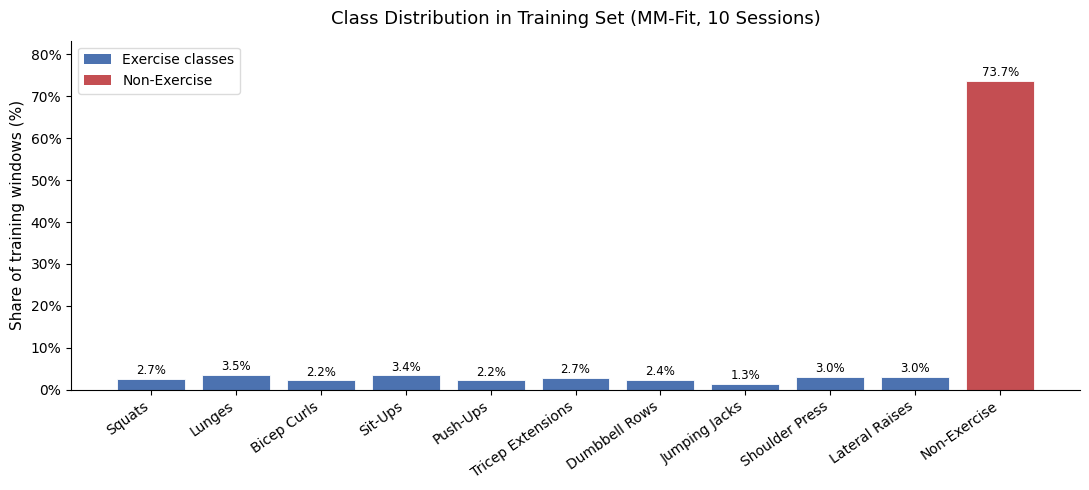

Saved: class_distribution_train.png


In [12]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
CLASS_LABELS = [
    "Squats", "Lunges", "Bicep Curls", "Sit-Ups", "Push-Ups",
    "Tricep Extensions", "Dumbbell Rows", "Jumping Jacks",
    "Shoulder Press", "Lateral Raises", "Non-Exercise",
]

percentages = counts / counts.sum() * 100

# Color: non-exercise highlighted
colors = ["#4C72B0"] * 10 + ["#C44E52"]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(range(N_CLASSES), percentages, color=colors, edgecolor="white", linewidth=0.6)

# Percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=8.5
    )

ax.set_xticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_LABELS, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Share of training windows (%)", fontsize=11)
ax.set_title("Class Distribution in Training Set (MM-Fit, 10 Sessions)", fontsize=13, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, percentages.max() * 1.13)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Exercise classes"),
    Patch(facecolor="#C44E52", label="Non-Exercise"),
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.7)

plt.tight_layout()
plt.savefig("class_distribution_train.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: class_distribution_train.png")